# Exemplo 12 - Problema de Sequenciamento de Tarefas

# 1. Configuração do Ambiente

Nesta etapa, configuramos o ambiente do Google Colab para utilizar a linguagem de otimização **CMPL**.

Essa célula deve ser executada apenas:
- Ao abrir o notebook pela primeira vez
- Ou quando o ambiente for reiniciado/desconectado

O que será feito:
- Download do COLIOP/CMPL (disponível em [coliop.org](https://www.coliop.org/download.html))
- Extração dos arquivos
- Configuração de variáveis de ambiente
- Inclusão das bibliotecas no Python

In [1]:
### Esta célula dever ser executada apenas quando o notebook for aberto
### ou quando o ambiente for desconectado e for necessário reconectá-lo
### por inatividade!

# Importação de bibliotecas do sistema
import os, sys

# Baixa o pacote do CMPL a partir do site oficial
os.system("wget https://www.coliop.org/_download/Cmpl-2-1-0-linux64.tar.gz")

# Extrai o arquivo baixado
os.system("tar -xzf Cmpl-2-1-0-linux64.tar.gz")

# Define o diretório principal do CMPL
os.environ["CMPLHOME"] = "/content/Cmpl-2-1-0-linux64"

# Adiciona o executável do CMPL ao PATH do sistema
os.environ["PATH"] += ":/content/Cmpl-2-1-0-linux64/bin"

# Configura bibliotecas compartilhadas necessárias
os.environ["LD_LIBRARY_PATH"] = "/content/Cmpl-2-1-0-linux64/bin/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

# Adiciona os módulos Python do CMPL ao caminho de importação
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/lib3")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/scripts/Unix")

# 2. Definição do Modelo de Otimização

Aqui definimos um problema de **programação inteira mista** usando a linguagem do CMPL.

## 2.1 Objetivo:
Minimizar a multa total por atrasos.

## 2.2 Elementos do modelo:
- **J**: Conjunto de tarefas.
- **Processamento**: Quantidade de horas necessárias para processar as tarefas na máquina.
- **Execução**: Quantidade de horas disponíveis (prazo) para execução das tarefas.
- **Multa**: Valor monetário aplicado para quantidade dias em atraso das tarefas.

## 2.3 Variável de decisão:
- `x[i,j]`: 1, se o advogado `i` for atribuído ao caso `j`; 0, caso contrário.

In [2]:
# Definição do modelo combinado (dados e generalização) em linguagem CMPL (como string)
codigo_cmpl = """

# Modelo de Sequenciamento em Máquina Única (Minimização de Multas)
# Linguagem: CMPL 2.1.0

par:
    # Conjunto de tarefas
    J := set(1..3);

    PROCESSAMENTO[J] := (5, 20, 15);
    EXECUCAO[J] := (25, 22, 35);
    MULTA[J] := (19, 12, 34);
    # Big-M: Soma de todos os tempos de processamento
    M := sum{j in J: PROCESSAMENTO[j]}; # Igual a 40 dias

var:
    x[J] : real[0..];

    t[J] : real[0..];

    y[J,J] : binary;

obj:
    multa_total: sum{j in J: MULTA[j]*t[j]} -> min;

con:
    AtrasoTarefa{j in J: t[j] >= x[j] + PROCESSAMENTO[j] - EXECUCAO[j];}
    Precedencia1{i in J, j in J, i<j: x[i] - x[j] + M*y[i,j] >= PROCESSAMENTO[j];}
    Precedencia2{i in J, j in J, i<j: x[j] - x[i] + M*(1 - y[i,j]) >= PROCESSAMENTO[i];}

"""

# Salva o modelo em um arquivo .cmpl
with open("/content/Exemplo-12_sequenciamento.cmpl", "w") as f:
    f.write(codigo_cmpl)

# 3. Resolução do Modelo

Nesta etapa utilizamos a **API Python pyCmpl** para fazer a integração entre modelo e resolvedor:
1. Carregamos o modelo criado
2. Executamos o solver
3. Exibimos o relatório da solução
4. Tratamento de erro para capturar possíveis problemas.

Também é possível fazer a entrada de dados por um arquivo python, atribuindo valores para conjuntos e parâmetros do modelo, utilizando atributos e métodos do pyCmpl. Isto será objeto para outra aula.

In [4]:
# Importa a biblioteca do CMPL para Python
from pyCmpl import *

try:
    # Cria o objeto do modelo a partir do arquivo
    modelo = Cmpl("/content/Exemplo-12_sequenciamento.cmpl")

    # Resolve o problema de otimização
    modelo.solve()

    # Exibe o relatório da solução (valores ótimos)
    modelo.solutionReport()

except CmplException as e:
    # Caso ocorra erro, exibe a mensagem
    print(e.msg)

---------------------------------------------------------------------------------------------------------
Problem              Exemplo-12_sequenciamento.cmpl
Nr. of variables     9
Nr. of constraints   9
Objective name       multa_total
Solver name          HIGHS
Display variables    (all)
Display constraints  (all)
---------------------------------------------------------------------------------------------------------

Objective status     INTEGER OPTIMAL
Objective value      170.00              (min!)

Variables           
Name                 Type            Activity          LowerBound          UpperBound            Marginal
---------------------------------------------------------------------------------------------------------
x[1]                    C               20.00                0.00                 inf                   -
x[2]                    C                0.00                0.00                 inf                   -
x[3]                    C               25.0

In [ ]:
#@title Função para visualização de dados
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast
import networkx as nx

def obter_matriz_solucao(variaveis):
    """
    Converte os valores das variáveis x[i,j] em uma
    matriz de solução.

    Parâmetros
    ----------
    variaveis : dict
        Dicionário no formato:
        {(i, j): valor}

    Retorna
    -------
    matriz_solucao : numpy.ndarray
        Matriz contendo os valores de x[i,j].

    funcionarios : list
        Lista dos índices dos funcionários.

    tarefas : list
        Lista dos índices das tarefas.
    """

    # Todos os funcionários e tarefas existentes em x
    funcionarios = sorted(
        set(indices[0] for indices in variaveis.keys())
    )

    tarefas = sorted(
        set(indices[1] for indices in variaveis.keys())
    )

    # Criar matriz inicialmente preenchida com zero
    matriz_solucao = np.zeros(
        (len(funcionarios), len(tarefas))
    )

    # Preencher a matriz
    for (i, j), valor in variaveis.items():

        linha = funcionarios.index(i)
        coluna = tarefas.index(j)

        matriz_solucao[linha, coluna] = valor

    return matriz_solucao, funcionarios, tarefas



# ============================================================
# 2. OBTER A SOLUÇÃO DO MODELO
# ============================================================

def obter_solucao_designacao(modelo):
    """
    Obtém as variáveis de decisão e as designações
    selecionadas na solução ótima.

    Retorna:
        variaveis
        designacoes
        valor_otimo
    """

    variaveis = {
        indices: elemento.activity
        for indices, elemento in modelo.x.items()
    }

    designacoes = []

    for indices, valor in variaveis.items():

        if valor > 0.5:

            i, j = indices

            designacoes.append((i, j))

    valor_otimo = modelo.solution.value

    return variaveis, designacoes, valor_otimo


def gerar_heatmap_designacao(
    matriz_solucao,
    funcionarios,
    tarefas,
    valor_otimo=None
):
    """
    Gera o heatmap da solução do problema de designação.

    Parâmetros
    ----------
    matriz_solucao : numpy.ndarray
        Matriz com os valores de x[i,j].

    funcionarios : list
        Índices dos funcionários.

    tarefas : list
        Índices das tarefas.

    valor_otimo : float, opcional
        Valor da função objetivo.
    """

    plt.figure(figsize=(10, 7))

    sns.heatmap(
        matriz_solucao,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        linewidths=1,
        linecolor="white",
        cbar_kws={
            "label": "Variável x[i,j]"
        },
        vmin=0,
        vmax=1
    )

    # --------------------------------------------------------
    # Título
    # --------------------------------------------------------

    titulo = "Solução Ótima do Problema de Designação"

    if valor_otimo is not None:
        titulo += f"\nValor ótimo = {valor_otimo:.0f}"

    plt.title(
        titulo,
        fontsize=16,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Eixos
    # --------------------------------------------------------

    plt.xlabel(
        "Tarefa",
        fontsize=12
    )

    plt.ylabel(
        "Funcionário",
        fontsize=12
    )

    # --------------------------------------------------------
    # Rótulos
    # --------------------------------------------------------

    plt.xticks(
        np.arange(len(tarefas)) + 0.5,
        [f"Tarefa {j}" for j in tarefas]
    )

    plt.yticks(
        np.arange(len(funcionarios)) + 0.5,
        [f"Funcionário {i}" for i in funcionarios],
        rotation=0
    )

    plt.tight_layout()
    plt.show()

def visualizar_heatmap_designacao(modelo):
    """
    Obtém a solução do modelo e gera automaticamente
    o heatmap do problema de designação.
    """

    # Obter solução
    variaveis, designacoes, valor_otimo = (
        obter_solucao_designacao(modelo)
    )

    # Criar matriz
    matriz_solucao, funcionarios, tarefas = (
        obter_matriz_solucao(variaveis)
    )

    # Gerar visualização
    gerar_heatmap_designacao(
        matriz_solucao,
        funcionarios,
        tarefas,
        valor_otimo
    )

    return matriz_solucao


def ler_matriz_cmpl(codigo_cmpl, nome_variavel="TEMPO"):
    """
    Lê uma matriz definida no código CMPL.

    Exemplo:
        TEMPO[I, J] := (
            (120, 150, 100, 100, 180),
            (100, 130, 120, 100, 220),
            ...
        );

    Retorna:
        numpy.ndarray
    """

    padrao = (
        rf"{re.escape(nome_variavel)}"
        r"\s*\[\s*I\s*,\s*J\s*\]\s*:=\s*\("
    )

    resultado = re.search(
        padrao,
        codigo_cmpl,
        re.IGNORECASE
    )

    if not resultado:
        raise ValueError(
            f"Variável '{nome_variavel}[I,J]' "
            "não encontrada em codigo_cmpl."
        )

    inicio = resultado.end() - 1

    nivel = 0
    fim = None

    for pos in range(inicio, len(codigo_cmpl)):

        if codigo_cmpl[pos] == "(":
            nivel += 1

        elif codigo_cmpl[pos] == ")":
            nivel -= 1

            if nivel == 0:
                fim = pos
                break

    if fim is None:
        raise ValueError(
            f"Não foi possível identificar o fim da matriz "
            f"'{nome_variavel}'."
        )

    texto = codigo_cmpl[inicio:fim + 1]

    try:
        matriz = ast.literal_eval(texto)

    except (ValueError, SyntaxError) as erro:
        raise ValueError(
            f"Não foi possível interpretar a matriz "
            f"'{nome_variavel}'."
        ) from erro

    return np.array(matriz, dtype=float)




# ============================================================
# 3. GERAR GRAFO DO PROBLEMA DE DESIGNAÇÃO
# ============================================================

def gerar_grafo_designacao(
    TEMPO,
    designacoes,
    valor_otimo=None,
    mostrar_todas=True
):
    """
    Gera o grafo bipartido do problema de designação.

    Parâmetros
    ----------
    TEMPO : matriz
        Matriz de tempos/custos.

    designacoes : lista
        Lista de tuplas (i, j) selecionadas pela solução ótima.

    valor_otimo : float, opcional
        Valor da função objetivo.

    mostrar_todas : bool
        Se True, mostra todas as possíveis designações.
        As escolhidas ficam destacadas em verde.
    """

    G = nx.Graph()

    numero_advogados = TEMPO.shape[0]
    numero_tarefas = TEMPO.shape[1]

    advogados = range(1, numero_advogados + 1)
    tarefas = range(1, numero_tarefas + 1)

    # --------------------------------------------------------
    # Criar nós
    # --------------------------------------------------------

    for i in advogados:

        G.add_node(
            f"A{i}",
            tipo="advogado",
            label=f"Advogado {i}"
        )

    for j in tarefas:

        G.add_node(
            f"T{j}",
            tipo="tarefa",
            label=f"Tarefa {j}"
        )

    # --------------------------------------------------------
    # Criar arestas
    # --------------------------------------------------------

    if mostrar_todas:

        for i in advogados:

            for j in tarefas:

                G.add_edge(
                    f"A{i}",
                    f"T{j}",
                    tempo=TEMPO[i - 1][j - 1]
                )

    else:

        for i, j in designacoes:

            G.add_edge(
                f"A{i}",
                f"T{j}",
                tempo=TEMPO[i - 1][j - 1]
            )

    # --------------------------------------------------------
    # Posição dos nós
    # --------------------------------------------------------

    pos = {}

    for indice, i in enumerate(advogados):
        pos[f"A{i}"] = (0, -indice)

    for indice, j in enumerate(tarefas):
        pos[f"T{j}"] = (3, -indice)

    # --------------------------------------------------------
    # Identificar arestas ótimas
    # --------------------------------------------------------

    arestas_otimas = {
        (f"A{i}", f"T{j}")
        for i, j in designacoes
    }

    # --------------------------------------------------------
    # Cores e espessuras
    # --------------------------------------------------------

    cores = []
    larguras = []

    for u, v in G.edges():

        if (u, v) in arestas_otimas or (v, u) in arestas_otimas:

            cores.append("#2ECC71")
            larguras.append(4)

        else:

            cores.append("#D3D3D3")
            larguras.append(1)

    # --------------------------------------------------------
    # Criar figura
    # --------------------------------------------------------

    plt.figure(figsize=(15, 9))

    # Advogados
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=[f"A{i}" for i in advogados],
        node_color="#3498DB",
        node_size=3000,
        node_shape="o",
        edgecolors="black",
        linewidths=1.5
    )

    # Tarefas
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=[f"T{j}" for j in tarefas],
        node_color="#F39C12",
        node_size=3000,
        node_shape="s",
        edgecolors="black",
        linewidths=1.5
    )

    # Arestas
    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=cores,
        width=larguras,
        alpha=0.85
    )

    # --------------------------------------------------------
    # Rótulos
    # --------------------------------------------------------

    labels = {}

    for i in advogados:
        labels[f"A{i}"] = f"Advogado {i}"

    for j in tarefas:
        labels[f"T{j}"] = f"Tarefa {j}"

    nx.draw_networkx_labels(
        G,
        pos,
        labels,
        font_size=10,
        font_weight="bold"
    )

    # --------------------------------------------------------
    # Mostrar somente os tempos das designações ótimas
    # --------------------------------------------------------

    labels_otimos = {}

    for i, j in designacoes:

        u = f"A{i}"
        v = f"T{j}"

        if G.has_edge(u, v):

            labels_otimos[(u, v)] = TEMPO[i - 1][j - 1]

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=labels_otimos,
        font_size=10,
        font_weight="bold",
        font_color="#006400",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        )
    )

    # --------------------------------------------------------
    # Título
    # --------------------------------------------------------

    titulo = "Problema de Designação — Solução Ótima"

    if valor_otimo is not None:
        titulo += f"\nValor ótimo = {valor_otimo:.0f} horas"

    plt.title(
        titulo,
        fontsize=18,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Legenda
    # --------------------------------------------------------

    plt.text(
        1.5,
        -max(numero_advogados, numero_tarefas) - 0.5,
        "🟢 Verde = designação selecionada\n"
        "⚪ Cinza = possibilidade não selecionada",
        ha="center",
        fontsize=11
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return G, pos

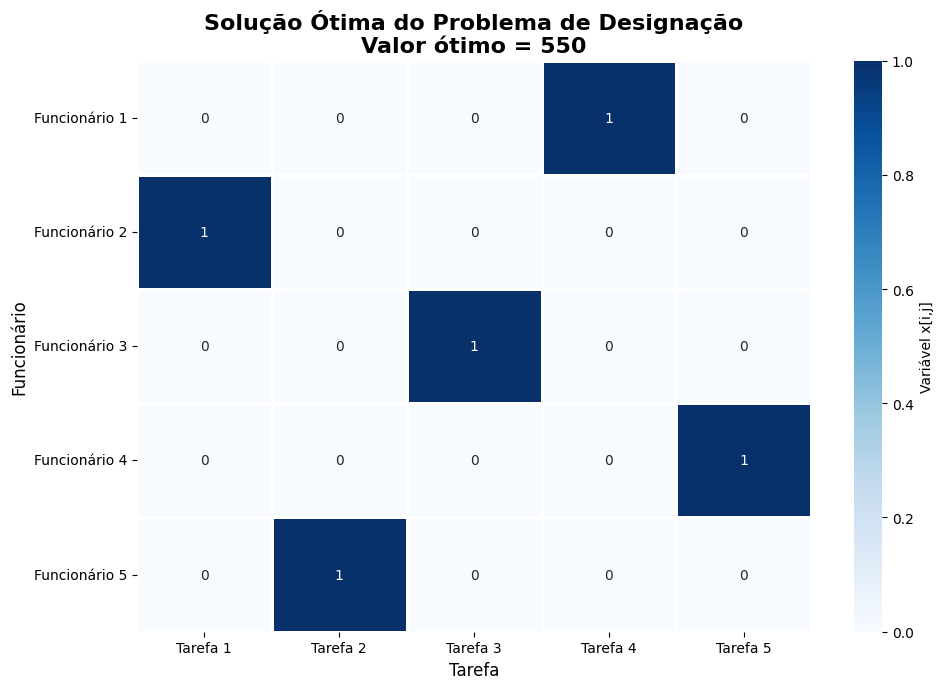

In [ ]:
matriz_solucao = visualizar_heatmap_designacao(modelo)

/tmp/ipykernel_3500/918947119.py:518: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


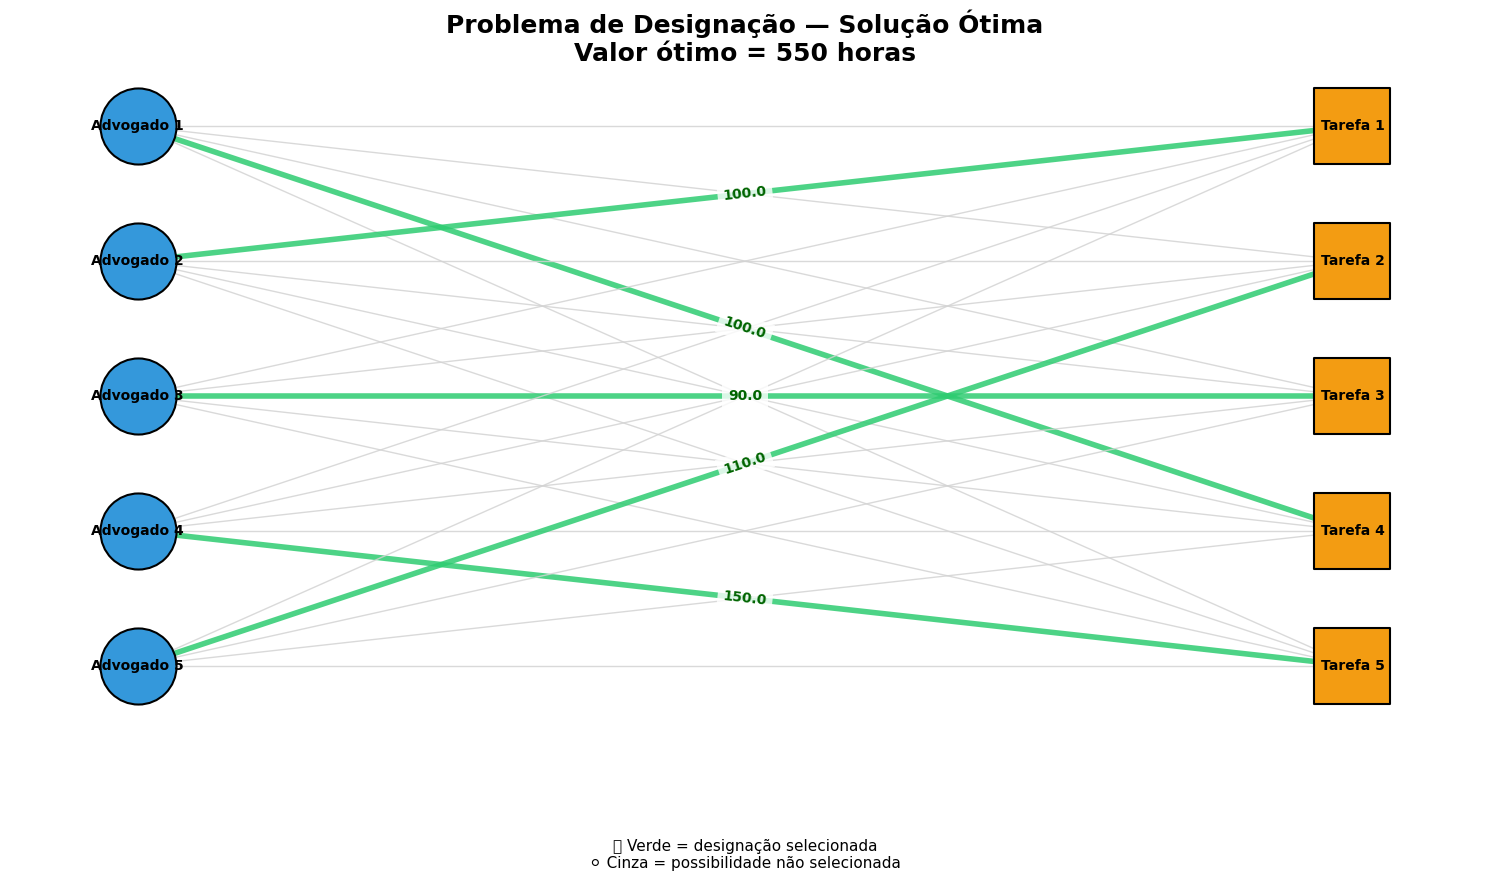

In [ ]:
# Ler matriz diretamente do código CMPL
TEMPO = ler_matriz_cmpl(codigo_cmpl)

# Obter solução
variaveis, designacoes, valor_otimo = obter_solucao_designacao(modelo)

# Gerar grafo
G, pos = gerar_grafo_designacao(
    TEMPO,
    designacoes,
    valor_otimo
)

# Source code

The source code is available on Github:
Cmpl official realeases: https://github.com/coin-or/Cmpl

Cmpl working git: https://github.com/MikeSteglich/Cmpl2

Coliop: https://github.com/MikeSteglich/Coliop

pyCmpl: https://github.com/MikeSteglich/pyCmpl3